In [2]:
!pip install openml

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns


from sklearn.model_selection import StratifiedKFold, train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn import svm
import optuna
from optuna.samplers import TPESampler
from scipy.stats import wilcoxon
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import statsmodels.api as sm
from sklearn.feature_selection import VarianceThreshold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.stats import t
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import f_classif

from sklearn.metrics import roc_curve, auc
import copy
from sklearn.metrics import confusion_matrix
from sklearn.base import clone

In [25]:
from sklearn.neighbors import KNeighborsClassifier

dataset = openml.datasets.get_dataset(61)

X, y, _, attribute_names = dataset.get_data(target=dataset.default_target_attribute)

d = pd.concat([X, y], axis=1)

np.unique(list(d['class']),return_counts=True)

data = pd.DataFrame(d)
data["class_int"] = pd.factorize(data["class"])[0]
data.drop(columns="class", inplace=True)
data

,sepallength,sepalwidth,petallength,petalwidth,class_int
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


,sepallength,sepalwidth,petallength,petalwidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


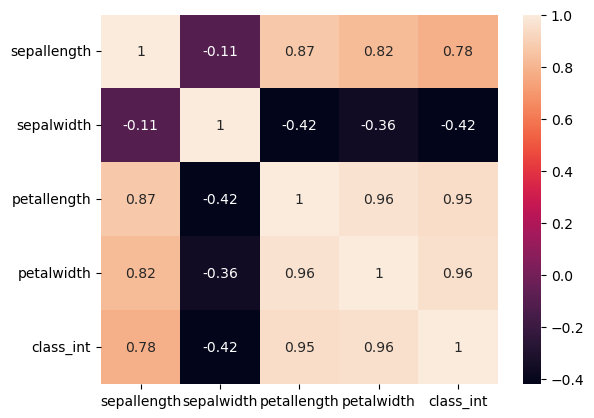

In [40]:
sns.heatmap(data.corr(), annot=True)
X = data.iloc[:, :4]
y = data["class_int"]
X

In [51]:
def create_pipeline(model, n_features):
    if model == "LogisticRegression":
        base_model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=500)
        steps = [("scaler", StandardScaler()),
             ("rfe", RFE(estimator=clone(base_model), n_features_to_select=n_features)),
             ("model", clone(base_model))]
    elif model == "KNeighborsClassifier":
        base_model = KNeighborsClassifier()
        steps = [("scaler", StandardScaler()),
             ("model", clone(base_model))]
    pipeline = Pipeline(steps)

    return pipeline

In [52]:
import warnings

warnings.filterwarnings("ignore")

def objective(trial):
    n_features = trial.suggest_int("n_features", 1, X.shape[1])
    model_choice = trial.suggest_categorical("model", ["LogisticRegression", "KNeighborsClassifier"])

    pipeline = create_pipeline(model_choice, n_features)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")

    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
    
    

[I 2025-11-30 19:57:16,828] A new study created in memory with name: no-name-1962ac50-9ba3-4f8a-98c3-472471c7b487
[I 2025-11-30 19:57:16,895] Trial 0 finished with value: 0.9733333333333334 and parameters: {'n_features': 1, 'model': 'KNeighborsClassifier'}. Best is trial 0 with value: 0.9733333333333334.
[I 2025-11-30 19:57:16,939] Trial 1 finished with value: 0.9733333333333334 and parameters: {'n_features': 1, 'model': 'KNeighborsClassifier'}. Best is trial 0 with value: 0.9733333333333334.
[I 2025-11-30 19:57:16,987] Trial 2 finished with value: 0.9533333333333334 and parameters: {'n_features': 4, 'model': 'LogisticRegression'}. Best is trial 0 with value: 0.9733333333333334.
[I 2025-11-30 19:57:17,056] Trial 3 finished with value: 0.9533333333333334 and parameters: {'n_features': 4, 'model': 'LogisticRegression'}. Best is trial 0 with value: 0.9733333333333334.
[I 2025-11-30 19:57:17,139] Trial 4 finished with value: 0.9400000000000001 and parameters: {'n_features': 1, 'model': 'Lo

In [53]:
best_val_lr = 0
best_val_knn = 0

for trial in study.trials:
    if trial.params["model"] == "LogisticRegression":
        if trial.value > best_val_lr:
            best_val_lr = trial.value
            best_lr_params = trial.params
    elif trial.params["model"] == "KNeighborsClassifier":
        if trial.value > best_val_knn :
            best_val_knn = trial.value
            best_knn_params = trial.params

print("Best LR params:", best_lr_params, "Accuracy:", best_val_lr)
print("Best KNN params:", best_knn_params, "Accuracy:", best_val_knn)


Best LR params: {'n_features': 4, 'model': 'LogisticRegression'} Accuracy: 0.9533333333333334
Best KNN params: {'n_features': 1, 'model': 'KNeighborsClassifier'} Accuracy: 0.9733333333333334


In [55]:
best_lr_model = create_pipeline("LogisticRegression", best_lr_params["n_features"])
best_knn_model = create_pipeline("KNeighborsClassifier", best_knn_params["n_features"])

best_lr_model.fit(X, y)
best_knn_model.fit(X, y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_val_score(best_lr_model, X, y, cv=cv, scoring="accuracy")
scores_knn = cross_val_score(best_knn_model, X, y, cv=cv, scoring="accuracy")

stat, p = wilcoxon(scores_lr, scores_knn)
print("Wilcoxon stat:", stat)
print("p-value:", p)

Wilcoxon stat: 0.0
p-value: 0.5


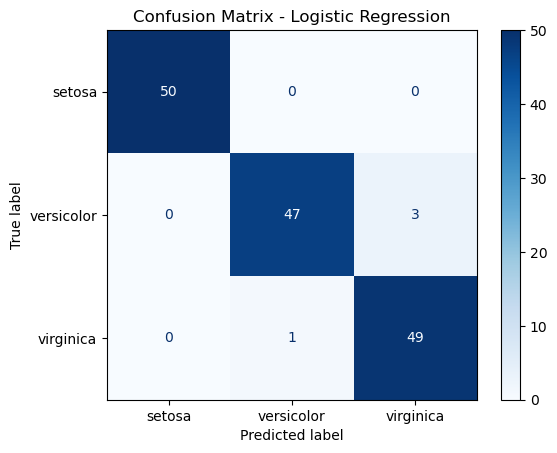

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_lr = best_lr_model.predict(X)
cm_lr = confusion_matrix(y, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
